# 에어 피팅 조립 상태 데이터 — EDA

[AI Hub 에어 피팅 조립 상태 데이터](https://aihub.or.kr/aihubdata/data/view.do?dataSetSn=71927) 샘플(`Air_Fitting_Type_Detection.zip`)의 탐색적 데이터 분석(EDA)입니다.

| 항목 | 내용 |
|------|------|
| 데이터 | 단품 에어피팅 + 중간 조립모듈 |
| 구성 | JPG 260장 + JSON 260개 |
| 라벨 | 단품: 메타데이터 / 조립모듈: B-box + 피팅 유형·체결상태 |
| 목적 | YOLOv11 에어피팅 **종류 검출** 학습 전 데이터 이해 |

<br>

> AI Hub 권장 모델: **YOLOv11** (에어피팅 종류 검출, 목표 mAP 70%+)  
> 다음 단계: `15_YOLO11_Air_Fitting_Detection.ipynb`

## 0. 환경 설정

In [1]:
import json
import shutil
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if not (ROOT / "Air_Fitting_Type_Detection.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "Air_Fitting_Type_Detection.zip").exists():
            ROOT = parent
            break

ZIP_PATH = ROOT / "Air_Fitting_Type_Detection.zip"
DATA_ROOT = ROOT / "air_fitting"
EDA_OUT = DATA_ROOT / "eda"

RAW_DIR_NAME = "01.원천데이터"
LABEL_DIR_NAME = "02.라벨링데이터"
SINGLE_KEY = "단품에어피팅"
MODULE_KEY = "중간조립모듈"


def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    jpgs = [p for p in root.rglob("*.jpg") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*.json") if "eda" not in p.parts]
    return len(jpgs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f"압축 파일이 없습니다: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            name = info.filename if (info.flag_bits & 0x800) else info.filename.encode("cp437").decode("cp949")
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())


def find_raw_and_label_roots(root: Path) -> tuple[Path, Path]:
    raw, label = root / RAW_DIR_NAME, root / LABEL_DIR_NAME
    if raw.exists() and label.exists():
        return raw, label
    candidates = [p for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return (
        max(candidates, key=lambda p: len(list(p.rglob("*.jpg")))),
        max(candidates, key=lambda p: len(list(p.rglob("*.json")))),
    )


def find_subdir(parent: Path, keyword: str) -> Path:
    for p in parent.iterdir():
        if p.is_dir() and keyword in p.name:
            return p
    raise FileNotFoundError(f"'{keyword}' 하위 폴더를 찾을 수 없습니다: {parent}")


print(f"ROOT      : {ROOT.resolve()}")
print(f"ZIP 존재  : {ZIP_PATH.exists()}")
print(f"데이터 준비: {data_is_ready(DATA_ROOT)}")
print(f"한글 경로 : {has_correct_korean_paths(DATA_ROOT)}")

ROOT      : C:\MyCursorLab\06_Object_Detection
ZIP 존재  : True
데이터 준비: False
한글 경로 : False


## 1. 압축 해제 및 폴더 구조

In [2]:
DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"zip 파일이 없습니다: {ZIP_PATH}")

need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
extract_zip(ZIP_PATH, DATA_ROOT, force=need_extract)
print("압축 해제 완료" if need_extract else "데이터 폴더 사용 (이미 압축 해제됨)")

EDA_OUT.mkdir(parents=True, exist_ok=True)
raw_root, label_root = find_raw_and_label_roots(DATA_ROOT)
raw_single = find_subdir(raw_root, SINGLE_KEY)
raw_module = find_subdir(raw_root, MODULE_KEY)
label_single = find_subdir(label_root, SINGLE_KEY)
label_module = find_subdir(label_root, MODULE_KEY)

print(f"원본 데이터 : {raw_root.name}")
print(f"  단품 에어피팅  : {len(list(raw_single.glob('*.jpg')))}장")
print(f"  중간 조립모듈  : {len(list(raw_module.glob('*.jpg')))}장")
print(f"라벨 데이터 : {label_root.name}")
print(f"  단품 JSON : {len(list(label_single.glob('*.json')))}개")
print(f"  조립 JSON : {len(list(label_module.glob('*.json')))}개")

압축 해제 완료
원본 데이터 : 01.원천데이터
  단품 에어피팅  : 60장
  중간 조립모듈  : 200장
라벨 데이터 : 02.라벨링데이터
  단품 JSON : 60개
  조립 JSON : 200개


## 2. 메타데이터 수집

In [3]:
def parse_single_record(json_path: Path) -> dict:
    data = json.loads(json_path.read_text(encoding="utf-8-sig"))
    img = data["images"]
    return {
        "dataset": "단품에어피팅",
        "file_name": img["file_name"],
        "product_maker": img.get("Product_maker"),
        "product_code": img.get("Product_code"),
        "product_material": img.get("Product_material"),
        "product_classification": img.get("Product_classification"),
        "tube_dia": img.get("Product_tube_dia"),
        "thread_size": img.get("Product_thread_size"),
        "illumination": img.get("Environ_Illumination_lx"),
        "width": img["Img_resolution"][0],
        "height": img["Img_resolution"][1],
        "num_annotations": 0,
        "json_path": str(json_path),
    }


def parse_module_record(json_path: Path) -> dict:
    data = json.loads(json_path.read_text(encoding="utf-8-sig"))
    img = data["images"]
    anns = data.get("Annotation", [])
    bbox_areas, part_types = [], []
    for ann in anns:
        x1, y1, x2, y2 = ann["Annotation_bbox"]
        bbox_areas.append((x2 - x1) * (y2 - y1))
        part_types.append(ann["Annotation_part_type"])
    return {
        "dataset": "중간조립모듈",
        "file_name": img["file_name"],
        "inspection_method": img.get("Inspection_method"),
        "photo_angle": img.get("Photo_angle"),
        "product_maker": img.get("Product_maker"),
        "application_field": img.get("Application_field"),
        "application_fluid": img.get("Application_fluid"),
        "part_type_count": img.get("Part_type_count"),
        "part_fitting_count": img.get("Part_fitting_count"),
        "illumination": img.get("Environ_Illumination_lx"),
        "width": img["Img_resolution"][0],
        "height": img["Img_resolution"][1],
        "num_annotations": len(anns),
        "part_types": ", ".join(part_types),
        "avg_bbox_area": float(np.mean(bbox_areas)) if bbox_areas else 0,
        "json_path": str(json_path),
    }


single_rows = [parse_single_record(p) for p in sorted(label_single.glob("*.json"))]
module_rows = [parse_module_record(p) for p in sorted(label_module.glob("*.json"))]
df_single = pd.DataFrame(single_rows)
df_module = pd.DataFrame(module_rows)

print(f"단품 레코드: {len(df_single)}")
print(f"조립 레코드: {len(df_module)}")
display(df_single.head(3))
display(df_module.head(3))

단품 레코드: 60
조립 레코드: 200


,dataset,file_name,product_maker,product_code,product_material,product_classification,tube_dia,thread_size,illumination,width,height,num_annotations,json_path
0,단품에어피팅,D1PHT-04-1O4_01.jpg,㈜씨디씨뉴매틱,D1PHT-04-1/4,복합체,원터치 피팅,4 mm,1/4 inch,1418,1920,1200,0,c:\MyCursorLab\06_Object_Detection\air_fitting...
1,단품에어피팅,D1PHT-04-1O4_02.jpg,㈜씨디씨뉴매틱,D1PHT-04-1/4,복합체,원터치 피팅,4 mm,1/4 inch,1418,1920,1200,0,c:\MyCursorLab\06_Object_Detection\air_fitting...
2,단품에어피팅,D1PHT-04-1O4_03.jpg,㈜씨디씨뉴매틱,D1PHT-04-1/4,복합체,원터치 피팅,4 mm,1/4 inch,1418,1920,1200,0,c:\MyCursorLab\06_Object_Detection\air_fitting...


,dataset,file_name,inspection_method,photo_angle,product_maker,application_field,application_fluid,part_type_count,part_fitting_count,illumination,width,height,num_annotations,part_types,avg_bbox_area,json_path
0,중간조립모듈,Module_001_A_CV_00_0001.jpg,직선이동 검사 환경,0°,㈜엠스코,조선·해양·해운 등 선박,압축공기,3,5,1422,1920,1200,2,"KRPUC형, KRPPL형",12930.0,c:\MyCursorLab\06_Object_Detection\air_fitting...
1,중간조립모듈,Module_001_A_CV_00_0002.jpg,직선이동 검사 환경,0°,㈜엠스코,조선·해양·해운 등 선박,압축공기,3,5,1422,1920,1200,2,"KRPUC형, KRPPL형",13783.5,c:\MyCursorLab\06_Object_Detection\air_fitting...
2,중간조립모듈,Module_001_A_CV_00_0003.jpg,직선이동 검사 환경,0°,㈜엠스코,조선·해양·해운 등 선박,압축공기,3,5,1422,1920,1200,2,"KRPUC형, KRPPL형",14410.5,c:\MyCursorLab\06_Object_Detection\air_fitting...


## 3. 분포 시각화

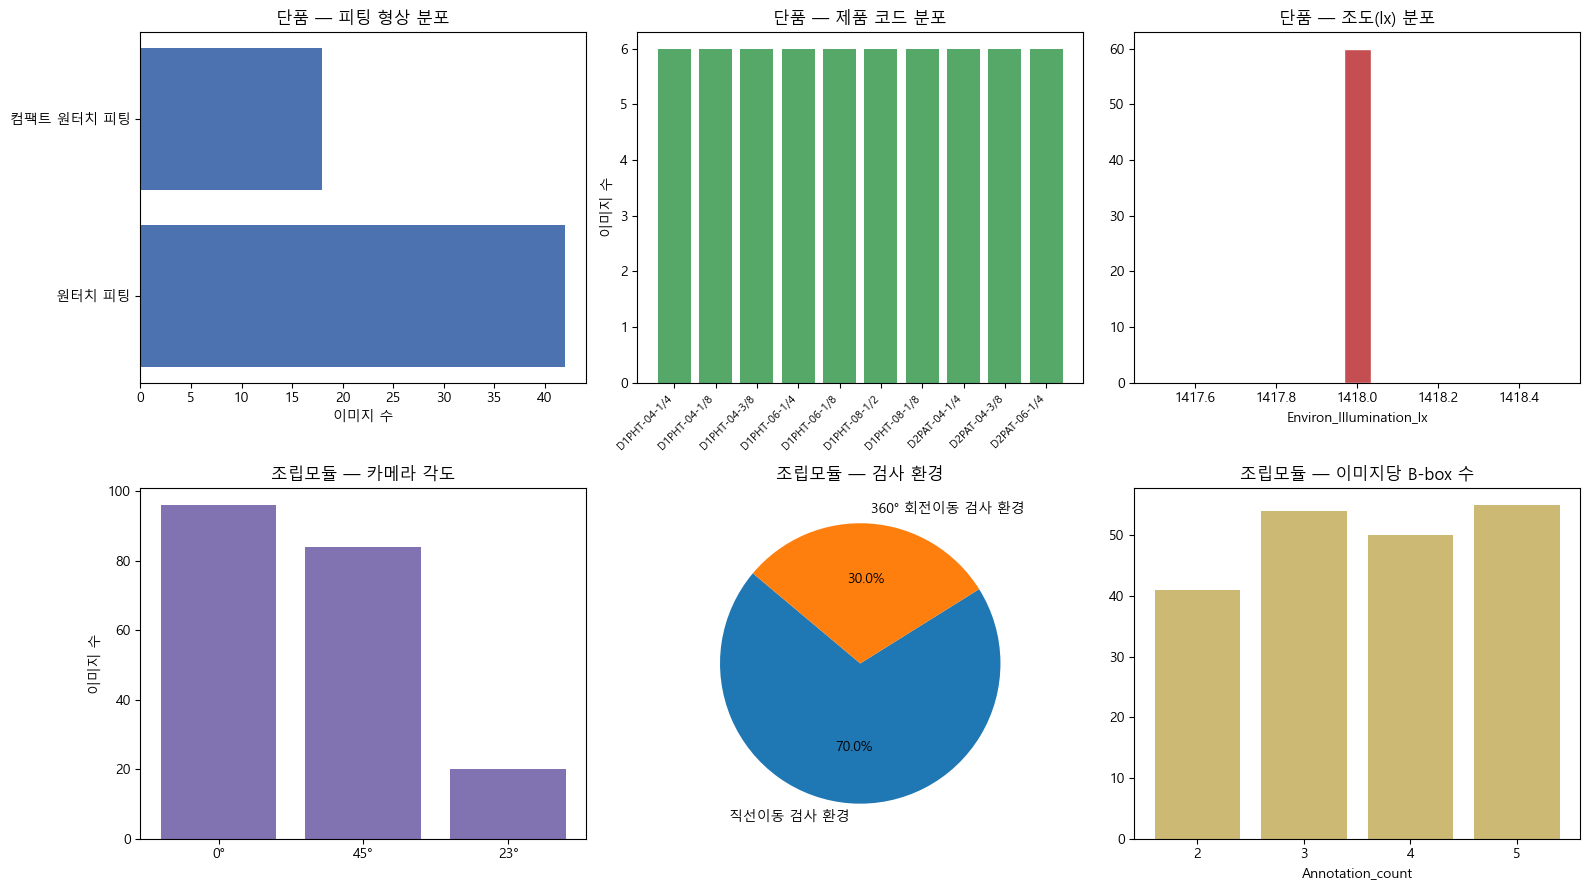

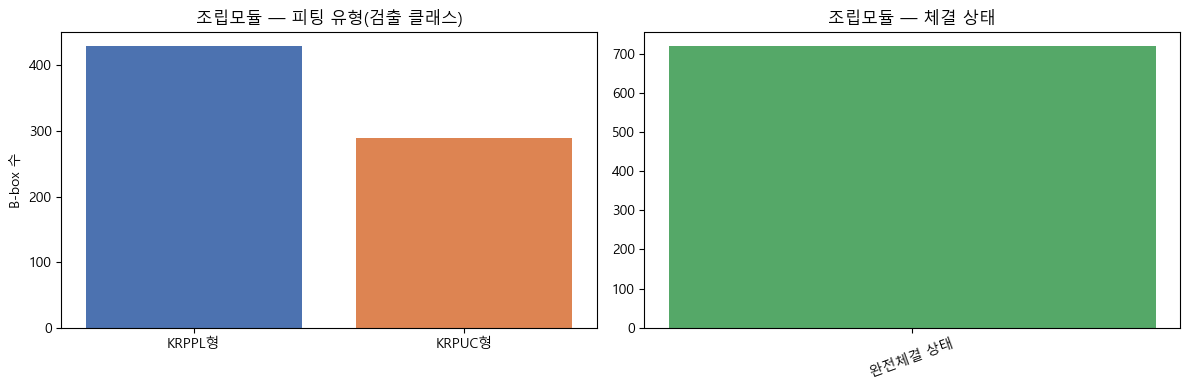

검출 클래스: {'KRPUC형': 290, 'KRPPL형': 429}
체결 상태: {'완전체결 상태': 719}


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

cls_cnt = df_single["product_classification"].value_counts()
axes[0, 0].barh(cls_cnt.index, cls_cnt.values, color="#4C72B0")
axes[0, 0].set_title("단품 — 피팅 형상 분포")
axes[0, 0].set_xlabel("이미지 수")

code_cnt = df_single["product_code"].value_counts().sort_index()
axes[0, 1].bar(range(len(code_cnt)), code_cnt.values, color="#55A868")
axes[0, 1].set_xticks(range(len(code_cnt)), code_cnt.index, rotation=45, ha="right", fontsize=8)
axes[0, 1].set_title("단품 — 제품 코드 분포")
axes[0, 1].set_ylabel("이미지 수")

axes[0, 2].hist(df_single["illumination"].dropna(), bins=15, color="#C44E52", edgecolor="white")
axes[0, 2].set_title("단품 — 조도(lx) 분포")
axes[0, 2].set_xlabel("Environ_Illumination_lx")

angle_cnt = df_module["photo_angle"].value_counts()
axes[1, 0].bar(angle_cnt.index.astype(str), angle_cnt.values, color="#8172B2")
axes[1, 0].set_title("조립모듈 — 카메라 각도")
axes[1, 0].set_ylabel("이미지 수")

method_cnt = df_module["inspection_method"].value_counts()
axes[1, 1].pie(method_cnt.values, labels=method_cnt.index, autopct="%1.1f%%", startangle=140)
axes[1, 1].set_title("조립모듈 — 검사 환경")

ann_cnt = df_module["num_annotations"].value_counts().sort_index()
axes[1, 2].bar(ann_cnt.index.astype(str), ann_cnt.values, color="#CCB974")
axes[1, 2].set_title("조립모듈 — 이미지당 B-box 수")
axes[1, 2].set_xlabel("Annotation_count")

plt.tight_layout()
plt.savefig(EDA_OUT / "distribution_overview.png", dpi=120, bbox_inches="tight")
plt.show()

part_type_counter, status_counter = Counter(), Counter()
for p in label_module.glob("*.json"):
    data = json.loads(p.read_text(encoding="utf-8-sig"))
    for ann in data.get("Annotation", []):
        part_type_counter[ann["Annotation_part_type"]] += 1
        status_counter[ann["Subclass_status"]] += 1

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pt = pd.Series(part_type_counter).sort_values(ascending=False)
ax[0].bar(pt.index, pt.values, color=["#4C72B0", "#DD8452"][: len(pt)])
ax[0].set_title("조립모듈 — 피팅 유형(검출 클래스)")
ax[0].set_ylabel("B-box 수")
st = pd.Series(status_counter)
ax[1].bar(st.index, st.values, color="#55A868")
ax[1].set_title("조립모듈 — 체결 상태")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(EDA_OUT / "detection_classes.png", dpi=120, bbox_inches="tight")
plt.show()
print("검출 클래스:", dict(part_type_counter))
print("체결 상태:", dict(status_counter))

## 4. 샘플 이미지 + 라벨 시각화

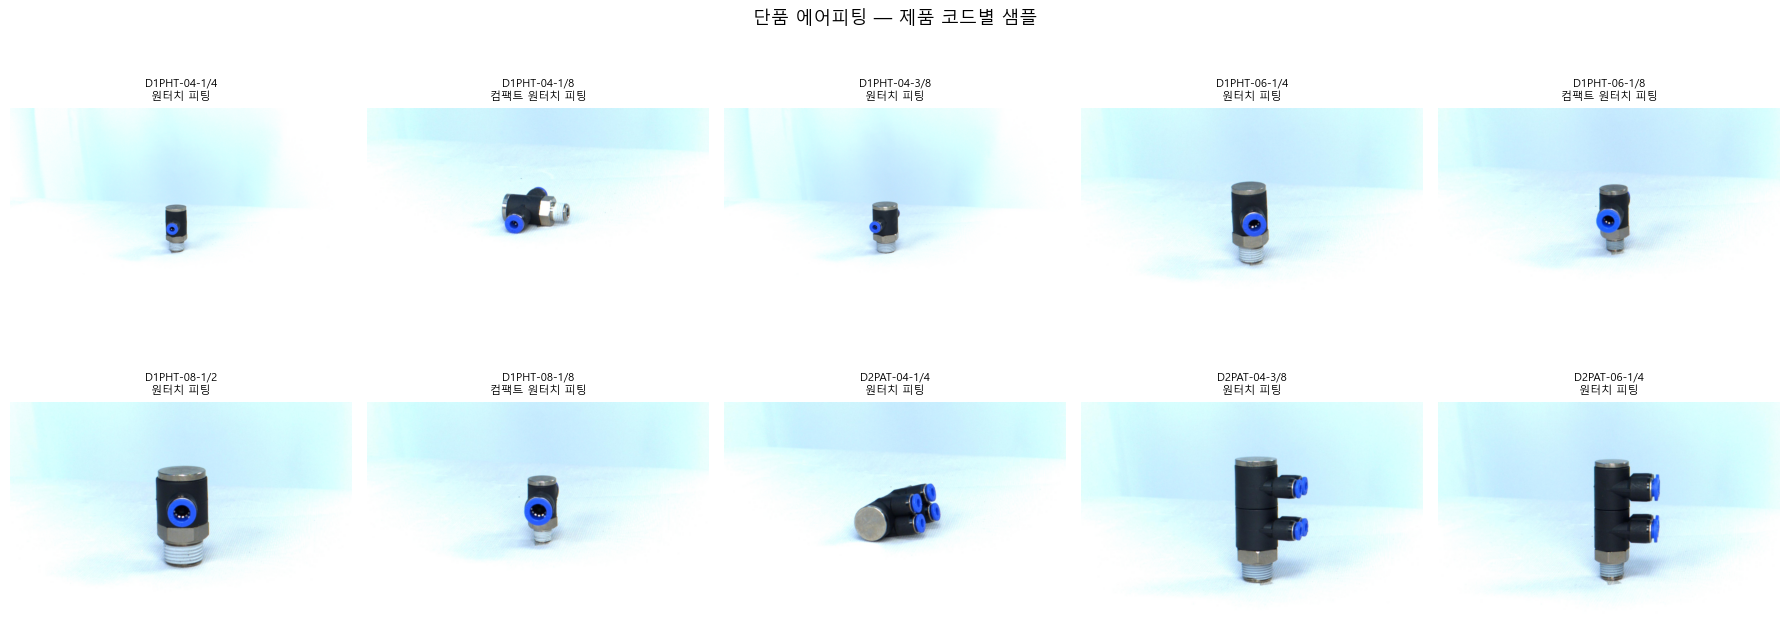

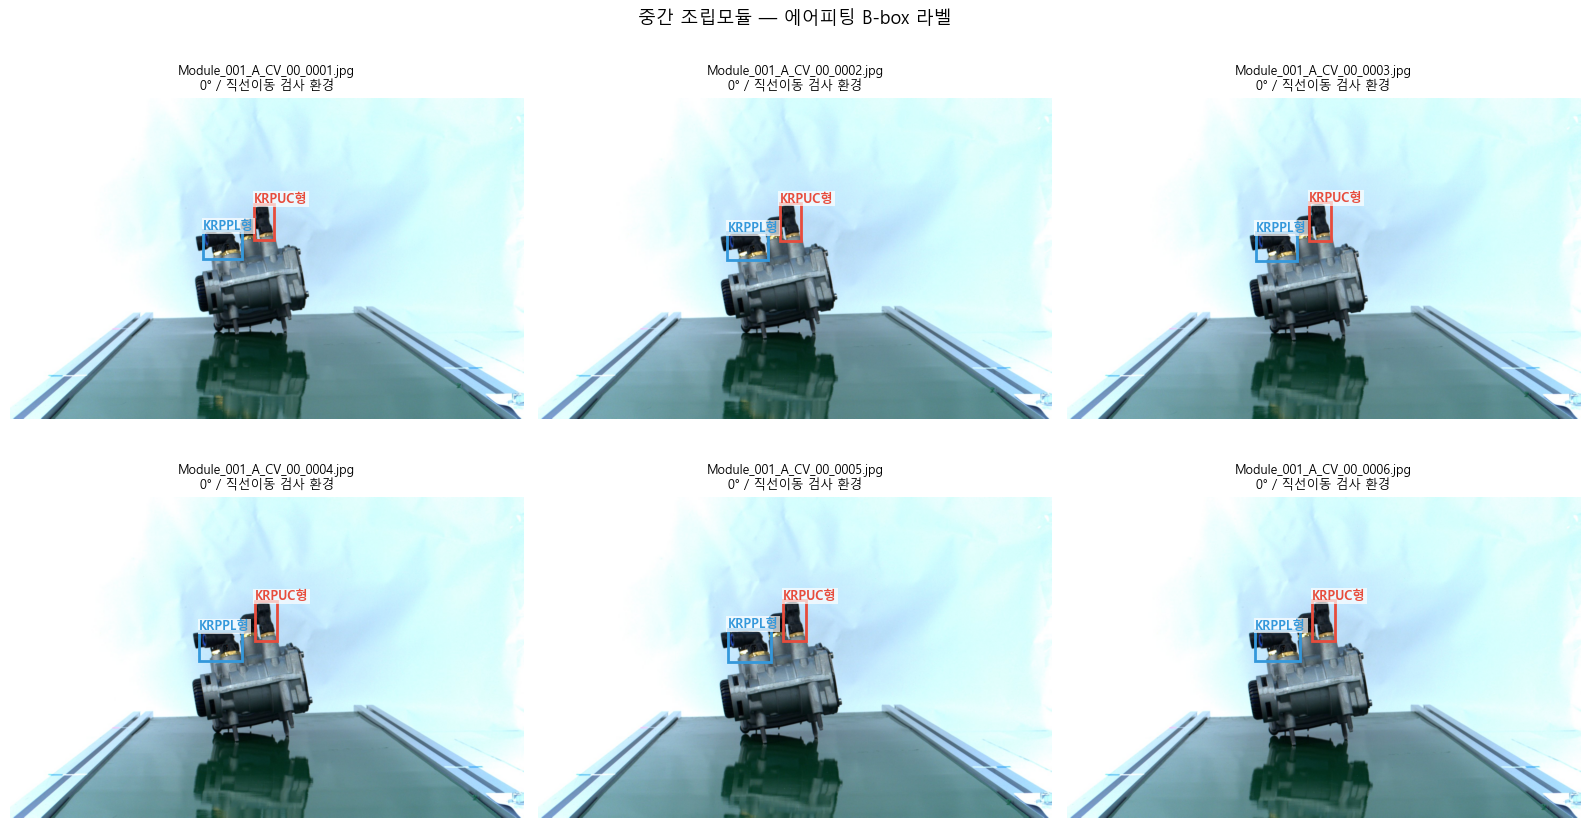

In [6]:
PART_COLORS = {"KRPUC형": "#E74C3C", "KRPPL형": "#3498DB"}


def draw_module_bboxes(ax, json_path: Path, img_path: Path):
    data = json.loads(json_path.read_text(encoding="utf-8-sig"))
    ax.imshow(Image.open(img_path))
    for ann in data.get("Annotation", []):
        x1, y1, x2, y2 = ann["Annotation_bbox"]
        label = ann["Annotation_part_type"]
        color = PART_COLORS.get(label, "#2ECC71")
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, label, color=color, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1))
    meta = data["images"]
    angle = meta.get("Photo_angle", "")
    method = meta.get("Inspection_method", "")
    ax.set_title(f"{meta['file_name']}\n{angle} / {method}", fontsize=9)
    ax.axis("off")


fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, (_, row) in zip(axes.flat, df_single.drop_duplicates("product_code").head(10).iterrows()):
    ax.imshow(Image.open(raw_single / row["file_name"]))
    ax.set_title(f"{row['product_code']}\n{row['product_classification']}", fontsize=8)
    ax.axis("off")
fig.suptitle("단품 에어피팅 — 제품 코드별 샘플", fontsize=13)
plt.tight_layout()
plt.savefig(EDA_OUT / "single_samples.png", dpi=120, bbox_inches="tight")
plt.show()

sample_jsons = sorted(label_module.glob("*.json"))[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, jp in zip(axes.flat, sample_jsons):
    meta = json.loads(jp.read_text(encoding="utf-8-sig"))["images"]
    draw_module_bboxes(ax, jp, raw_module / meta["file_name"])
fig.suptitle("중간 조립모듈 — 에어피팅 B-box 라벨", fontsize=13)
plt.tight_layout()
plt.savefig(EDA_OUT / "module_bbox_samples.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. 바운딩박스 통계

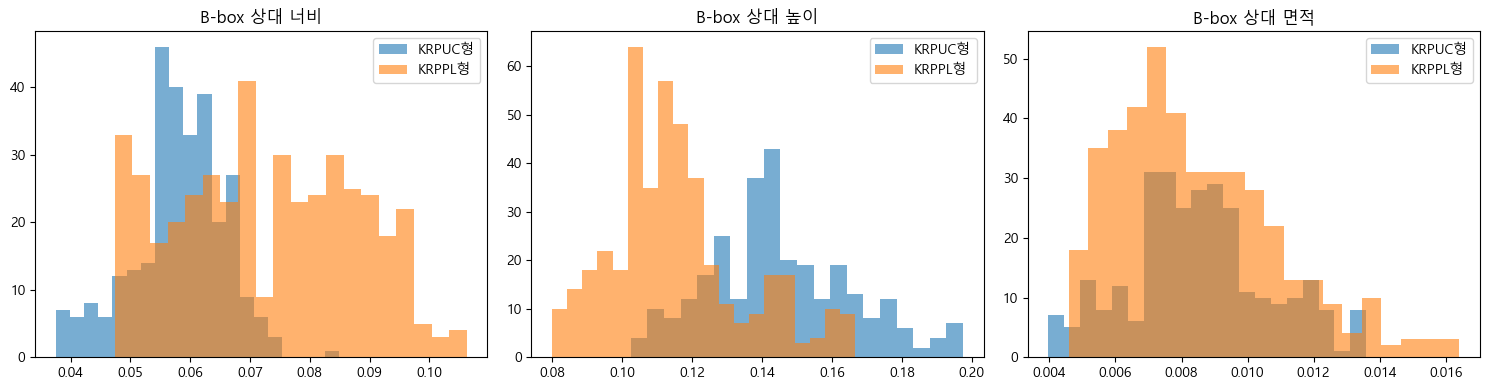

bbox_w                      bbox_h                    rel_area  \
               mean      std min  max      mean      std  min  max     mean   
part_type                                                                     
KRPPL형     139.5315  28.8636  91  204  138.6853  22.7028   96  200   0.0084   
KRPUC형     111.5172  14.7876  72  163  173.9931  24.6376  123  237   0.0085   

                                   
              std     min     max  
part_type                          
KRPPL형     0.0025  0.0046  0.0164  
KRPUC형     0.0021  0.0040  0.0136

In [7]:
bbox_rows = []
for jp in label_module.glob("*.json"):
    data = json.loads(jp.read_text(encoding="utf-8-sig"))
    w, h = data["images"]["Img_resolution"]
    for ann in data.get("Annotation", []):
        x1, y1, x2, y2 = ann["Annotation_bbox"]
        bw, bh = x2 - x1, y2 - y1
        bbox_rows.append({
            "part_type": ann["Annotation_part_type"],
            "bbox_w": bw,
            "bbox_h": bh,
            "bbox_area": bw * bh,
            "rel_w": bw / w,
            "rel_h": bh / h,
            "rel_area": (bw * bh) / (w * h),
        })

df_bbox = pd.DataFrame(bbox_rows)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ["rel_w", "rel_h", "rel_area"], ["상대 너비", "상대 높이", "상대 면적"]):
    for pt in df_bbox["part_type"].unique():
        sub = df_bbox[df_bbox["part_type"] == pt][col]
        ax.hist(sub, bins=20, alpha=0.6, label=pt)
    ax.set_title(f"B-box {title}")
    ax.legend()
plt.tight_layout()
plt.savefig(EDA_OUT / "bbox_stats.png", dpi=120, bbox_inches="tight")
plt.show()

display(df_bbox.groupby("part_type")[["bbox_w", "bbox_h", "rel_area"]].agg(["mean", "std", "min", "max"]).round(4))

## 6. EDA 요약

| 항목 | 관찰 |
|------|------|
| 데이터 규모 | 단품 60장 + 조립모듈 200장 (샘플) |
| 검출 대상 | 조립모듈 `Annotation_part_type` (KRPUC형, KRPPL형 등) |
| B-box 형식 | `[x1, y1, x2, y2]` 절대좌표 → YOLO 정규화 변환 필요 |
| 단품 데이터 | 분류 메타데이터만 제공 (B-box 없음) |
| 카메라 각도 | 0° / 23° / 45° — 검증셋 분리 기준으로 활용 |

<br>

> 다음 단계: `15_YOLO11_Air_Fitting_Detection.ipynb`